# Agent, RAG & Tool Evaluation — Master Reference

This notebook is the consolidated, single-source-of-truth reference for evaluating **RAG pipelines, tool-calling agents, and multi-turn conversational agents** in this repo. It merges, cell-for-cell and without deletions, the content of two source notebooks:

1. `multi-turn eval and tool evaluations/evaluation.ipynb` — multi-turn conversational evaluation, DeepEval's three dedicated tool-use metrics, and task-completion evaluation.
2. `04_Agent_RAG_Eval/rag_agent_eval_langgraph_new.ipynb` and `04_Agent_RAG_Eval/rag_agent_eval_langgraph_openai.ipynb` — retrieval/RAG metrics, a full DeepEval RAG metric suite, and a 9-metric agent-trajectory evaluation harness, each demonstrated first with deterministic mocks and then with a real OpenAI-backed LangGraph agent.

Nothing was removed from the originals — they remain unchanged at their original paths for standalone reference and provenance. Every section below is annotated with the source notebook it came from.

## Before running this notebook

- **Environment / kernel:** the two source notebook groups were built against slightly different pinned dependency sets — `evaluation.ipynb`'s folder pins `deepeval==3.8.8`; `04_Agent_RAG_Eval/requirements.txt` pins `deepeval==3.1.0`; the repo root `.venv` (this notebook's default kernel) has `deepeval==4.1.8`. All metrics used below (`ConversationalGEval`, `TurnRelevancyMetric`, `KnowledgeRetentionMetric`, `ToolCorrectnessMetric`, `ArgumentCorrectnessMetric`, `ToolUseMetric`, `TaskCompletionMetric`, `ContextualRelevancyMetric`, `FaithfulnessMetric`, `AnswerRelevancyMetric`, `GEval`) are present in `4.1.8` — if you run this against an older pinned env instead, double check a given metric class still exists there before relying on it.
- **Credentials:** you need an OpenAI-compatible key available via `.env` (`OPENAI_API_KEY`, optionally `OPENAI_BASE_URL` if routing through OpenRouter — see `multi-turn eval and tool evaluations/.env.example`). Every DeepEval-judged metric and every "real OpenAI" agent/RAG section below makes live API calls and will incur cost.
- **Windows async note:** Part 6 explicitly sets `async_mode=False` on every DeepEval metric — DeepEval's default async judge-call path was observed to hang indefinitely on Windows in that notebook's environment even though a synchronous call from the same environment returns in under 2 seconds. Carried forward here for the same reason; drop it if your environment doesn't hit this.
- **Execution order matters, but each Part is self-contained.** Several Parts below define their own `RAGEvalState`, `AgentEvalState`, `builder`, etc. Later Parts intentionally redefine the same names when moving from a mocked scenario to a real one — that's expected (each Part's cells were designed to run top-to-bottom as a self-contained unit in their original notebook), not a bug. Run Parts in order, top to bottom.

## Table of contents

| Part | Covers | Source |
|---|---|---|
| [Part 1](#part-1) | Multi-turn conversational evaluation (`ConversationalGEval`, `TurnRelevancyMetric`, `KnowledgeRetentionMetric`, safe-advice, conversation simulation) | `evaluation.ipynb` |
| [Part 2](#part-2) | Tool use evaluation (`ToolCorrectnessMetric`, `ArgumentCorrectnessMetric`, `ToolUseMetric`) | `evaluation.ipynb` |
| [Part 3](#part-3) | Task completion evaluation (`TaskCompletionMetric`, custom `GEval` rubric, outcome/state verification) | `evaluation.ipynb` |
| [Part 4](#part-4) | Retrieval metrics — deterministic (`precision_at_k`) and a mocked RAG eval graph (context relevance, faithfulness, as hand-rolled LangGraph judge nodes) | `rag_agent_eval_langgraph_new.ipynb` |
| [Part 5](#part-5) | Agent trajectory evaluation — mocked: a simple agent eval graph, then a realistic refund-agent scenario scored on **9 separate trace-level metrics** (tool selection accuracy, argument correctness, redundant calls, step-wise accuracy, task success rate, fuzzy trajectory match, end-state verification, recovery rate, cost/efficiency proxy) + a Databricks implementation mapping table | `rag_agent_eval_langgraph_new.ipynb` |
| [Part 6](#part-6) | Retrieval + full RAG metric suite — real OpenAI calls (`ContextualRelevancyMetric`, `FaithfulnessMetric`, `AnswerRelevancyMetric`, Answer Correctness via `GEval`, Answer Semantic Similarity via embeddings) | `rag_agent_eval_langgraph_openai.ipynb` |
| [Part 7](#part-7) | Agent trajectory evaluation — real OpenAI tool-calling agent (`search_docs`, `calculator`, `send_email` tools bound to a live LLM) | `rag_agent_eval_langgraph_openai.ipynb` |

**Quick lookup — "which metric answers which question":** see the summary table at the end of Part 3, and the two summary tables at the end of Part 5 and Part 6/7.

<a id="part-1"></a>
# Part 1 — Multi-Turn Conversational Evaluation

_Source: `multi-turn eval and tool evaluations/evaluation.ipynb`, cells 1-12 (unmodified)._

## Implementing multi-turn evaluation with DeepEval


DeepEval provides a practical framework for multi-turn evaluation. It represents a dialogue as a ```ConversationalTestCase```, which is a sequence of Turns. We then apply the conversational metrics.

In [ ]:
from deepeval.metrics import ConversationalGEval
from deepeval.metrics import TurnRelevancyMetric, KnowledgeRetentionMetric
from deepeval.test_case import ConversationalTestCase, Turn, MultiTurnParams
from dotenv import load_dotenv
load_dotenv()

In [ ]:
# A (simulated) medical chatbot conversation
test_case = ConversationalTestCase(
    scenario="Patient describes symptoms and asks for advice.",
    expected_outcome="Chatbot asks follow-up questions and recommends seeing a doctor.",
    turns=[
        Turn(role="user",      content="Hi, I've had a sore throat for two days."),
        Turn(role="assistant", content="""Sorry to hear that!
                                        Do you have any fever or trouble swallowing?"""),
        Turn(role="user",      content="Yes, mild fever around 38°C."),
        Turn(role="assistant", content="""With a sore throat and mild fever,
                                        it could be a bacterial or viral infection.
                                        I'd recommend seeing a doctor. In the meantime,
                                        stay hydrated and rest."""),
        Turn(role="user",      content="Should I take paracetamol?"),
        Turn(role="assistant", content="""Paracetamol can help with fever and throat pain.
                                        Take it as directed by the doctor"""),
    ]
)

In [ ]:
# Metrics
relevancy = TurnRelevancyMetric(
    threshold=0.7, model="gpt-4o")
retention = KnowledgeRetentionMetric(
    threshold=0.7, model="gpt-4o")
safe_advice = ConversationalGEval(
    name="Safe Medical Advice",
    evaluation_params=[MultiTurnParams.ROLE, MultiTurnParams.CONTENT],
    criteria="""The assistant should never diagnose,
            always recommend a doctor for serious concerns,
            and give safe, helpful guidance.""",
    threshold=0.6,
    model="gpt-4o",
    # strict_mode=True, (for higher determinism in results)
)

In [ ]:
relevancy.measure(test_case)
retention.measure(test_case)
safe_advice.measure(test_case)

print(f"Turn Relevancy: {relevancy.score}, Reason: {relevancy.reason}")
print(f"Knowledge Retention: {retention.score}, Reason: {retention.reason}")
print(
    f"Safe Medical Advice: {safe_advice.score}, Reason: {safe_advice.reason}")

This script, instead of evaluating a single prompt-response pair, evaluates an entire dialogue between a user and an assistant.

The `ConversationalTestCase` and `Turn` classes are used to represent the conversation itself. Each message in the dialogue is represented as a `Turn`, with a role and the corresponding message content.

After defining the conversation, the script initializes three evaluation metrics:
- `TurnRelevancyMetric` constructs sliding windows of turns for each turn, before using the LLM to determine whether the last turn in every sliding window has an "assistant" content that is relevant to the previous conversational context found in the sliding window.
- `KnowledgeRetentionMetric` evaluates whether the assistant correctly remembers and uses information from earlier turns in the conversation.
- `safe_advice`, a `ConversationalGEval` metric, which is a modified implementation of standard G-Eval LLM-as-judge evaluation. Using this we can determine whether our LLM chatbot responses are up to standard with our custom criteria throughout the conversation.

All three metrics are configured with thresholds and an evaluation model (`gpt-4o`).

The script then runs the evaluations in a standalone manner by calling `.measure(test_case)` on each metric.

```While we could also use evaluate(), standalone execution is useful for debugging or when integrating results into our own application or pipelines. The trade-off is that we won’t receive benefits like integration with the Confident AI platform, that the evaluate() function provides.```

Overall, this example illustrates how with DeepEval we can evaluate multi-turn dialogue quality, checking for relevance, context retention, and domain-specific safety rules.

Apart from these, DeepEval provides several other multi-turn evaluation metrics. We encourage readers to explore them in the documentation as a self-learning activity.

Introduction to LLM Evaluation Metrics https://deepeval.com/docs/metrics-introduction?ref=dailydoseofds.com

### Conversation simulation

For broader coverage with lesser manual effort, one can build simulated users that interact with the bot. A simulator has a predefined goal and a policy for how to pursue it, including curveballs like changing requirements mid-conversation.

At the end of the simulated conversation, evals can be incorporated to check whether the goal was met or not. This gives you an automatic success signal that could scale to hundreds of scenarios.

In DeepEval we have `ConversationSimulator` that synthesizes multi-turn dialogues from defined user intents. This saves substantial manual effort compared to writing test dialogues by hand.

Alternatively, we can also directly use LLMs as user simulators. Simply prompt a model to behave as an angry customer, a confused user, or someone who keeps changing their mind. The key requirement is having a clear way to determine success from the resulting conversation.

Conversation Simulator: https://deepeval.com/docs/conversation-simulator?ref=dailydoseofds.com

<a id="part-2"></a>
# Part 2 — Tool Use Evaluation

_Source: `multi-turn eval and tool evaluations/evaluation.ipynb`, cells 13-19 (unmodified)._

## Evaluating tool use in LLM systems

Tool use is the heart of any LLM agent. Regardless of how well an agent reasons or plans, if it calls the wrong function, passes malformed arguments, or invokes tools in the wrong sequence, the task fails. And here is the tricky part: the final text output can look perfectly plausible even when the tool execution underneath was completely broken. A travel bot that confidently says "Your flight is booked!" is useless if it never actually called the booking API.

This makes tool use evaluation fundamentally different from standard LLM evaluation, and arguably the most important dimension for agentic systems.

### Why tool use evaluation requires its own approach

In a standard LLM evaluation, you feed a prompt to a model and compare the output against a reference answer. With tool-using systems, the output is only the tip of the iceberg. Beneath it lies a sequence of decisions: which tools to invoke, in what order, with what arguments, and how to interpret the results. Each of these decisions is a potential failure point, and each requires its own evaluation.

Consider a customer support agent with access to three tools: `OrderLookup`, `PolicyRetriever`, and `RefundProcessor`. A user asks about returning an item from order #12345. The correct behavior is to first look up the order, then retrieve the return policy, and finally process the refund if eligible.

But it might happen that the agent skips the lookup and hallucinates order details. Or it might call the right tools but pass the wrong order ID. Or it might call `RefundProcessor` before checking whether the item is even eligible. The final response could sound correct in all these cases, but only a tool-level evaluation would catch the underlying failures.

Tool evaluation therefore asks a specific set of questions that traditional evaluation ignores:
- Did the agent select the right tools?
- Did the agent call tools in the correct order?
- Did the agent supply correct arguments?

DeepEval provides three dedicated metrics for evaluating tool use, each targeting a different dimension and operating at a different level of granularity:
- **`ToolCorrectnessMetric`** — reference-based, compares `tools_called` against `expected_tools`. Great for regression/CI when you already know the correct tool behavior.
- **`ArgumentCorrectnessMetric`** — referenceless, LLM-judged evaluation of whether the arguments passed to each tool call were correct given the task. Ideal for dynamic workflows and production monitoring where exact argument values can't be predetermined.
- **`ToolUseMetric`** — multi-turn version, operates on a `ConversationalTestCase`. Produces a tool selection score and an argument correctness score, with the final score being the minimum of both.

### Tool evaluation with DeepEval

Let's now see how we can utilize the DeepEval framework for tool evaluations, walking through each of the three dedicated tool metrics with concrete examples.

#### `ToolCorrectnessMetric`: reference-based tool evaluation metric

The `ToolCorrectnessMetric` is the most direct tool evaluation metric. It compares the tools actually called (`tools_called`) against a known expected set (`expected_tools`). This also makes it a reference-based metric, i.e., you must know in advance which tools should have been called.

This example shows how to evaluate whether the right tools were used in the right way during a task. Instead of judging the final text output, it checks the actual tool usage against what we expected it to do:
- `ToolCall` represents an individual tool details/invocation, and `ToolCallParams` lets you specify what parts of each tool call should be compared during evaluation. `ToolCorrectnessMetric` is the metric that performs the comparison.
- The `available_tools` list defines the tools that were theoretically available to the agent. Each tool is described with a name, input schema, and a short description. This list is optional, but if provided, DeepEval can additionally judge whether the agent actually chose the most appropriate tools from all possible options.
- The `expected_tools` section within `test_case` defines the reference behavior.
- Finally, the `ToolCorrectnessMetric` configuration controls how strict the evaluation should be. By including `ToolCallParams.INPUT_PARAMETERS`, the metric checks whether the tool arguments match. By including `ToolCallParams.OUTPUT`, it also checks whether the recorded outputs align.
- The `should_exact_match=True` setting makes the evaluation stricter. It requires the actual tool calls and expected tool calls to match exactly. That means extra tools, missing tools, mismatched details or wrong order of tool calling can be penalized.
- The commented-out `available_tools=available_tools` line shows an optional enhancement. If enabled, DeepEval can use an LLM judge to determine whether the chosen tools were the optimal choices from the set of available tools. In that mode, the final score becomes more conservative, because it combines the deterministic matching with an LLM-based judgment of tool selection quality.

Overall, this metric is great for development, testing, and regression checks. It works especially well when you already know what the correct tool behavior should look like.

In [ ]:
from deepeval.test_case import LLMTestCase, ToolCall, ToolCallParams
from deepeval.metrics import ToolCorrectnessMetric
from dotenv import load_dotenv
load_dotenv()

available_tools = [
    ToolCall(name="FlightSearch",
             input_parameters={"origin": "str",
                               "destination": "str", "date": "str"},
             description="Search flights tool"),
    ToolCall(name="WeatherCheck",
             input_parameters={"city": "str", "date": "str"},
             description="Check weather for a city"),
    ToolCall(name="HotelSearch",
             input_parameters={"city": "str",
                               "check_in": "str", "check_out": "str"},
             description="Search hotels in a city"),
    ToolCall(name="CurrencyConvert",
             input_parameters={"from": "str", "to": "str", "amount": "float"},
             description="Convert from one currency to another"),
    ToolCall(name="WeatherCheckV2",
             input_parameters={"city": "str", "date": "str"},
             description="Newer weather tool"),
]

test_case = LLMTestCase(
    input="Find me flights from NYC to London on 2026-03-13 and check the weather there.",
    actual_output="Found 2 flights from NYC to London. Weather in London: 12°C, cloudy.",

    tools_called=[
        ToolCall(
            name="FlightSearch",
            input_parameters={"origin": "NYC", "destination": "London",
                              "date": "2026-03-13"},
            output={"flights":
                    [{"id": "BA178", "price_usd": 412}, {
                        "id": "VS4", "price_usd": 389}],
                    "total": 2}
        ),
        ToolCall(
            name="WeatherCheck",
            input_parameters={"city": "London", "date": "2026-03-13"},
        ),
    ],

    expected_tools=[
        ToolCall(
            name="FlightSearch",
            input_parameters={"origin": "NYC", "destination": "London",
                              "date": "2026-03-13"},
            output={"flights":
                    [{"id": "BA178", "price_usd": 412}, {
                        "id": "VS4", "price_usd": 389}],
                    "total": 2}
        ),
        ToolCall(
            name="WeatherCheck",
            input_parameters={"city": "London", "date": "2026-03-13"},
        ),
    ],
)

metric = ToolCorrectnessMetric(
    evaluation_params=[
        ToolCallParams.INPUT_PARAMETERS,
        ToolCallParams.OUTPUT,
    ],
    should_exact_match=True,
    available_tools=available_tools,
    # model="gpt-4o",
    include_reason=True,
)

metric.measure(test_case)
print(f"Score: {metric.score}")
print(f"Reason: {metric.reason}")

#### `ArgumentCorrectnessMetric`: referenceless argument evaluation

The `ArgumentCorrectnessMetric` focuses specifically on whether the arguments (input parameters) passed to each tool call were correct for the given task. Unlike `ToolCorrectnessMetric`, this metric is fully referenceless and LLM-judged: it evaluates argument quality based on the user's input and the tool descriptions, without requiring expected argument values.

This example evaluates whether the right arguments are passed to a tool (but with an extra safety layer). It combines a manual schema validation step with DeepEval's `ArgumentCorrectnessMetric`. The manual validation catches obvious structural mistakes first, and only if that passes does the LLM-based metric run:
- The `TOOL_SCHEMAS` dictionary defines the expected argument structure for the `FlightSearch` tool. It says that this tool must receive exactly three keys: `origin`, `destination`, and `date`. It also defines a validator for the date field, where `datetime.strptime(v, "%Y-%m-%d")` is used to check that the value is a properly formatted date string.
- The `validate_args()` function is a deterministic guardrail. It loops through all tool calls made by the agent and checks whether a schema exists for that tool. If no schema is defined, it skips validation for that tool. For tools that do have a schema, it compares the provided argument keys against the required ones. And after the key checks, the function validates field formats. If all tools pass these checks, the function returns `True, "ok"`. That means the tool arguments are structurally valid and the script can proceed to the LLM-based evaluation.
- The `ArgumentCorrectnessMetric` itself is then defined with a threshold, an evaluation model, and `include_reason=True`. This metric is meant to judge whether the arguments passed to the tool are appropriate given the user's request, the tool description, and the overall context.
- The control flow at the end is important. First, `validate_args(test_case.tools_called)` is run. If that check fails, the script immediately prints `Score: 0` and the deterministic reason — the LLM metric is skipped entirely, because there is no point in evaluating clearly malformed tool call(s). If the validation passes, the script then calls `metric.measure(test_case)`. At that point, DeepEval uses the LLM judge to assess the correctness of the arguments more intelligently. The final printed score and reason then come from the metric rather than the manual validator.

So the overall pattern here is: first enforce hard input constraints deterministically, then check semantic correctness of arguments with DeepEval. This is a strong setup for agent evaluation because it separates the two kinds of correctness.

`ArgumentCorrectnessMetric`, owing to its nature, is ideal for two scenarios: dynamic workflows where the exact argument values cannot be predetermined, and production monitoring, since it does not require labeled data to produce a meaningful score.

In [ ]:
from deepeval.metrics import ArgumentCorrectnessMetric
from deepeval.test_case import LLMTestCase, ToolCall
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

TOOL_SCHEMAS = {
    "FlightSearch": {
        "required_keys": {"origin", "destination", "date"},
        "validators": {
            "date": (lambda v: datetime.strptime(v, "%Y-%m-%d"), "YYYY-MM-DD")
        }
    }
}


def validate_args(tools_called: list[ToolCall]) -> tuple[bool, str]:
    for tool in tools_called:
        schema = TOOL_SCHEMAS.get(tool.name)
        if not schema:
            continue

        actual_keys = set(tool.input_parameters.keys())
        required_keys = schema["required_keys"]

        missing = required_keys - actual_keys
        if missing:
            return False, f"{tool.name}: missing required args {missing}"

        extra = actual_keys - required_keys
        if extra:
            return False, f"{tool.name}: unexpected args {extra}"

        for field, (validator, fmt) in schema["validators"].items():
            value = tool.input_parameters.get(field)
            try:
                validator(value)
            except (ValueError, TypeError):
                return False, f"{tool.name}: '{field}' must be '{fmt}', got '{value}'"

    return True, "ok"


metric = ArgumentCorrectnessMetric(
    threshold=0.7,
    model="gpt-4o",
    include_reason=True,
)

test_case = LLMTestCase(
    input="Find me flights from New York to Paris on March 15, 2026",
    actual_output="I found 3 flights from NYC to Paris on March 15.",
    tools_called=[
        ToolCall(
            name="FlightSearch",
            description="Search for available flights between cities on a given date (date in YYYY-MM-DD format).",
            input_parameters={"origin": "NYC",
                              "destination": "Paris", "date": "2026-03-15"}
        ),
    ],
)

valid, reason = validate_args(test_case.tools_called)
if not valid:
    print(f"Score: 0\nReason: {reason}")
else:
    metric.measure(test_case)
    print(f"Score: {metric.score}\nReason: {metric.reason}")

#### `ToolUseMetric`: multi-turn tool evaluation

The `ToolUseMetric` evaluates tool usage across a multi-turn conversation. It operates on a `ConversationalTestCase`, making it the right choice for chatbot-style agents where tool use can span multiple exchanges.

The `ToolUseMetric` produces two sub-scores: a tool selection score and an argument correctness score. The final score is the minimum of both, so a failure in either dimension pulls the overall score down.

The `available_tools` parameter is required. By telling the metric which tools the agent could have used, you enable it to evaluate whether each selection was optimal given the alternatives.

This metric is most useful for evaluating conversational agents where tool use decisions depend on evolving context.

To summarize, the three metrics serve three key purposes:
- Use `ToolCorrectnessMetric` when you have labeled test cases with known expected tools. This is a great choice for regression testing and CI/CD pipelines.
- Use `ArgumentCorrectnessMetric` when you need to evaluate argument quality without reference data. This is the right choice for dynamic workflows, and cases where the exact argument values depend on runtime context.
- Use `ToolUseMetric` when evaluating multi-turn conversations where tool use spans multiple exchanges.

In [ ]:
from deepeval.metrics import ToolUseMetric
from deepeval.test_case import Turn, ConversationalTestCase, ToolCall
from dotenv import load_dotenv
load_dotenv()

convo_test_case = ConversationalTestCase(
    turns=[
        Turn(role="user", content="Find me a hotel in Paris for March 15-18, 2026"),
        Turn(
            role="assistant",
            content="I found one option. The Hotel Le Marais (id: 'le-marais-paris') has availability at $180/night.",
            tools_called=[
                ToolCall(
                    name="HotelSearch",
                    input_parameters={
                        "city": "Paris", "checkin": "2026-03-15", "checkout": "2026-03-18"},
                    output={"hotel_id": "le-marais-paris",
                            "name": "Le Marais", "price_usd": 180}
                )
            ]
        ),
        Turn(role="user", content="Yes, book the same please (id: 'le-marais-paris'), from 15 to 18 March."),
        Turn(
            role="assistant",
            content="Done! Your reservation is confirmed. Confirmation: HTL-9921.",
            tools_called=[
                ToolCall(
                    name="HotelBooking",
                    input_parameters={"hotel_id": "le-marais-paris",
                                      "checkin": "2026-03-15", "checkout": "2026-03-18"},
                    output={"confirmation": "HTL-9921"}
                )
            ]
        ),
    ],
)

metric = ToolUseMetric(
    model="gpt-4o",
    include_reason=True,
    available_tools=[
        ToolCall(name="HotelSearch",
                 description="Search for hotels by city and dates"),
        ToolCall(name="HotelBooking",
                 description="Book a hotel by hotel ID and dates"),
        ToolCall(name="FlightSearch",
                 description="Search for flights between cities"),
        ToolCall(name="CarRental", description="Search for rental cars"),
    ],
    # strict_mode=True,
)

metric.measure(convo_test_case)
print(f"Score: {metric.score}")
print(f"Reason: {metric.reason}")

<a id="part-3"></a>
# Part 3 — Task Completion Evaluation

_Source: `multi-turn eval and tool evaluations/evaluation.ipynb`, cells 20-24 (unmodified)._

## Evaluating task completion: does the output satisfy the requirement?

`ToolCorrectnessMetric`, `ArgumentCorrectnessMetric`, and `ToolUseMetric` all judge the *mechanics* of tool use: were the right tools picked, with the right arguments, in the right order. None of them ask the one question that actually matters to a user: **did the agent get the job done?**

That gap is real. An agent can call every tool correctly and still fail the task — it might book the wrong hotel because it ignored a stated budget, silently drop a constraint from a multi-part request, or hand back a technically-valid tool result wrapped in a confident sentence that doesn't reflect what actually happened. Conversely, a slightly inefficient tool-calling sequence can still land on a perfectly satisfactory outcome. Tool-level metrics and outcome-level metrics are answering different questions, and a production eval suite needs both.

#### `TaskCompletionMetric`: outcome-level evaluation

`TaskCompletionMetric` is DeepEval's dedicated metric for this. It's an LLM-judged, referenceless metric that looks at the `input` (the user's goal) together with the `actual_output` and `tools_called`, and asks: given everything the agent did, was the underlying task actually accomplished?

A few things worth knowing before using it:
- It only requires `input` and `actual_output` on the `LLMTestCase` — `tools_called` is optional but strongly recommended, since it's what lets the judge see *how* the outcome was reached, not just what the agent said happened.
- The `task` parameter is optional. If you don't pass it, the metric infers the task from `input` itself. Pass it explicitly when the real task is broader than the literal wording of the input (e.g. an implicit constraint mentioned earlier in a conversation).
- `requires_trace = True` on this metric class signals that it prefers a full execution trace (via DeepEval's `@observe` tracing) when one is available, since a trace captures intermediate reasoning that a flat `tools_called` list can't. When no trace is attached to the test case, it falls back to reasoning over `input` + `actual_output` + `tools_called` directly — which is exactly what the example below relies on, so no tracing setup is required to get useful signal out of it.

The example below deliberately constructs a case where the tool calls look fine in isolation, but the outcome violates a constraint stated in the request — the kind of failure `ToolCorrectnessMetric` cannot catch, because it only compares tool calls against `expected_tools`, not against the user's actual intent.

In [ ]:
from deepeval.metrics import TaskCompletionMetric
from deepeval.test_case import LLMTestCase, ToolCall
from dotenv import load_dotenv
load_dotenv()

# The agent called the right tools with well-formed arguments, and the hotel
# it booked is real — but it's $30/night over the budget the user stated.
# ToolCorrectnessMetric / ArgumentCorrectnessMetric would both score this well;
# TaskCompletionMetric is meant to catch that the actual requirement was not met.
test_case = LLMTestCase(
    input="Book a hotel in Paris for March 15-18, 2026, budget under $150/night.",
    actual_output="Booked! Your reservation at Hotel Le Marais is confirmed (HTL-9921).",
    tools_called=[
        ToolCall(
            name="HotelSearch",
            input_parameters={"city": "Paris",
                              "check_in": "2026-03-15", "check_out": "2026-03-18"},
            output={"hotel_id": "le-marais-paris",
                    "name": "Hotel Le Marais", "price_usd": 180}
        ),
        ToolCall(
            name="HotelBooking",
            input_parameters={"hotel_id": "le-marais-paris",
                              "check_in": "2026-03-15", "check_out": "2026-03-18"},
            output={"confirmation": "HTL-9921"}
        ),
    ],
)

metric = TaskCompletionMetric(
    threshold=0.7,
    model="gpt-4o",
    include_reason=True,
    # task="Book a hotel in Paris for the given dates, staying under $150/night",
)

metric.measure(test_case)
print(f"Score: {metric.score}")
print(f"Reason: {metric.reason}")

#### Beyond a single LLM-judge metric: custom rubrics and outcome verification

`TaskCompletionMetric` uses a fixed, general-purpose definition of "done." For most agents that's a reasonable default, but two situations call for going further:

**When "done" is domain-specific.** If your product has its own definition of success — e.g. "the summary must cite at least two sources" or "a refund response must never promise a specific dollar amount before policy lookup" — write it as a custom rubric with `GEval` instead of relying on the generic task-completion prompt:

```python
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCaseParams

task_success = GEval(
    name="Task Success",
    criteria="Given the user's request in `input`, determine whether `actual_output` "
             "fully satisfies every explicit constraint in the request (budget, dates, "
             "location, etc.), not just the general intent.",
    evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT],
    threshold=0.7,
)
```

This costs more to write — you have to spell out what "satisfies the requirement" means for your product — but it lets the judge apply the exact bar you care about instead of a generic one.

**When the stakes are high enough that an LLM judge isn't enough.** Both `TaskCompletionMetric` and a custom `GEval` rubric are still LLM-as-judge: they read text and reason about whether it *sounds* like the task was completed. For agents that take real actions (booking, sending, writing to a database), the strongest signal is to skip judging the text entirely and **verify the actual side effect** — e.g. after a "book the hotel" task, query the booking system directly for a confirmed reservation matching the requested dates and budget, rather than trusting the agent's sentence saying it booked one. This state-based check can't be fooled by a fluent-but-wrong response, and it's cheap and deterministic once you have access to the system the agent acted on. In practice, the two approaches complement each other: a deterministic state check as the pass/fail gate for tasks with a checkable outcome, and `TaskCompletionMetric` or a custom `GEval` rubric as a secondary quality signal for the cases where "correct" is inherently fuzzy (tone, completeness of an explanation, quality of a written summary).

**Summary — which metric answers which question:**

| Question | Metric |
| --- | --- |
| Were the right tools called, matching a known-good reference? | `ToolCorrectnessMetric` |
| Were the arguments passed to each tool correct, with no reference available? | `ArgumentCorrectnessMetric` |
| Was tool use appropriate across a multi-turn conversation? | `ToolUseMetric` |
| Did the agent actually accomplish what the user asked for? | `TaskCompletionMetric`, or a custom `GEval` rubric for a domain-specific bar |
| Did the real-world side effect actually happen, with no room for a fluent-but-wrong answer? | Deterministic state/outcome verification against the system the agent acted on |

<a id="part-4"></a>
# Part 4 — Retrieval & RAG Evaluation (Mocked, Deterministic)

_Source: `04_Agent_RAG_Eval/rag_agent_eval_langgraph_new.ipynb`, cells 1-15 (unmodified). Mock judge functions stand in for real LLM calls throughout this Part — see Part 6 for the real-OpenAI-calls counterpart of this same evaluation logic._

# RAG & Agent Evaluation — LangGraph Walkthrough

This notebook implements the evaluation concepts as **runnable LangGraph pipelines**, using mock tools/judges so everything runs with no API key.

**Structure:**
1. Part 1 — RAG retrieval metrics (Precision@K, Recall@K, MRR, nDCG)
2. Part 2 — RAG eval pipeline as a LangGraph graph (context relevance + faithfulness/groundedness)
3. Part 3 — Agent eval pipeline as a LangGraph graph (tool selection, task completion, trajectory scoring, unnecessary tool calls)

Each section starts with the interview question it answers, then the code that demonstrates it.

## Setup

```
pip install langgraph langchain-core
```

In [1]:
from typing import TypedDict, List, Dict, Optional
import math
from langgraph.graph import StateGraph, END

print("Imports OK")

Imports OK


---
# Part 1 — Retrieval Metrics

**Interview questions covered:**
- *How would you evaluate retrieval quality?*
- *What do Precision@K and Recall@K tell you?*
- *When would you use MRR or nDCG?*

**Approach:** build a labeled eval set (query → ground-truth relevant chunk IDs), run retrieval, score with rank-aware metrics — kept separate from generation quality so you can isolate *where* a RAG failure comes from.

In [2]:
def precision_at_k(retrieved: List[str], relevant: List[str], k: int) -> float:
    """Of the K chunks retrieved, how many are actually relevant?"""
    top_k = retrieved[:k]
    hits = [doc for doc in top_k if doc in relevant]
    return len(hits) / k if k > 0 else 0.0


def recall_at_k(retrieved: List[str], relevant: List[str], k: int) -> float:
    """Of all relevant chunks that exist, how many did we find in top K?"""
    top_k = retrieved[:k]
    hits = [doc for doc in top_k if doc in relevant]
    return len(hits) / len(relevant) if relevant else 0.0


def mrr(retrieved: List[str], relevant: List[str]) -> float:
    """Mean Reciprocal Rank: 1/rank of the FIRST relevant hit.
    Use when there's typically one correct/best chunk and you care how early it appears."""
    for rank, doc in enumerate(retrieved, start=1):
        if doc in relevant:
            return 1.0 / rank
    return 0.0


def dcg_at_k(retrieved: List[str], grades: Dict[str, int], k: int) -> float:
    score = 0.0
    for i, doc in enumerate(retrieved[:k]):
        rel = grades.get(doc, 0)
        score += rel / math.log2(i + 2)  # rank 1 -> log2(2)=1, avoids log2(1)=0 division
    return score


def ndcg_at_k(retrieved: List[str], grades: Dict[str, int], k: int) -> float:
    """Normalized DCG: use when relevance is GRADED (not binary) and multiple
    relevant chunks can coexist. Rewards relevant results appearing higher."""
    dcg = dcg_at_k(retrieved, grades, k)
    ideal_order = sorted(grades.values(), reverse=True)[:k]
    idcg = sum(rel / math.log2(i + 2) for i, rel in enumerate(ideal_order))
    return dcg / idcg if idcg > 0 else 0.0

print("Metric functions defined")

Metric functions defined


### Toy eval example

Query: *"What is the time complexity of BST delete?"*
- `retrieved_ids` — what the retriever actually returned, in rank order
- `relevant_ids` — ground truth (labeled once, reused across eval runs)
- `relevance_grades` — graded relevance (0-3) for nDCG; binary membership in `relevant_ids` is enough for Precision/Recall/MRR

In [3]:
query = "What is the time complexity of BST delete?"

retrieved_ids = ["chunk_3", "chunk_1", "chunk_7", "chunk_2", "chunk_9"]
relevant_ids  = ["chunk_1", "chunk_2", "chunk_5"]     # chunk_5 exists but wasn't retrieved -> hurts recall
relevance_grades = {
    "chunk_1": 3, "chunk_2": 2, "chunk_3": 0,
    "chunk_5": 3, "chunk_7": 1, "chunk_9": 0,
}

k = 5
print(f"Precision@{k}: {precision_at_k(retrieved_ids, relevant_ids, k):.2f}")
print(f"Recall@{k}:    {recall_at_k(retrieved_ids, relevant_ids, k):.2f}")
print(f"MRR:           {mrr(retrieved_ids, relevant_ids):.2f}")
print(f"nDCG@{k}:       {ndcg_at_k(retrieved_ids, relevance_grades, k):.2f}")

Precision@5: 0.40
Recall@5:    0.67
MRR:           0.50
nDCG@5:       0.51


**Reading the output:**
- Precision@5 = 0.40 → 2 of the 5 retrieved chunks were relevant (`chunk_1`, `chunk_2`). 3 were noise.
- Recall@5 = 0.67 → we found 2 of the 3 relevant chunks that exist; `chunk_5` was missed entirely.
- MRR = 0.50 → the first relevant chunk (`chunk_1`) appeared at rank 2, so 1/2.
- nDCG@5 factors in that `chunk_1` (grade 3) ranking below `chunk_3` (grade 0) is a bigger penalty than a small rank swap between two similarly-graded chunks would be.

---
# Part 2 — RAG Eval Pipeline as a LangGraph Graph

**Interview questions covered:**
- *How would you measure context relevance?*
- *How would you know the answer is grounded in the retrieved context?*

**Approach:** model the pipeline as a graph — `retrieve → judge_context_relevance → generate → check_faithfulness`. Each node writes eval signals into shared state. In production the "judge" functions below would be LLM calls (LLM-as-judge); here they're deterministic mocks so the notebook runs standalone.

- **Context relevance** = are the retrieved chunks actually about the query? (checked *before* generation)
- **Faithfulness/groundedness** = does the generated answer only assert things the context supports? (checked *after* generation, catches hallucination)

In [4]:
class RAGEvalState(TypedDict):
    query: str
    retrieved_chunks: List[Dict]
    relevance_judgments: Dict[str, str]     # chunk_id -> "relevant" / "irrelevant"
    answer: str
    claims: List[str]
    faithfulness_scores: Dict[str, bool]    # claim -> is it supported by context?
    context_relevance_score: float
    faithfulness_score: float

In [5]:
# ---- Mock "LLM-as-judge" functions ----
# In production: replace these with real LLM calls (e.g. "Is this chunk relevant to
# the query? yes/no", or "Is this claim entailed by the context? yes/no").

STOPWORDS = {"what", "is", "the", "of", "a", "an", "to", "in", "for", "and", "how"}

def mock_judge_relevance(query: str, chunk_text: str) -> str:
    query_terms = {w for w in query.lower().split() if w not in STOPWORDS and len(w) > 2}
    overlap = sum(1 for term in query_terms if term in chunk_text.lower())
    return "relevant" if overlap >= 1 else "irrelevant"

def mock_generate_answer(query: str, chunks: List[Dict]) -> str:
    relevant_text = " ".join(c["text"] for c in chunks)
    return f"Based on context: {relevant_text[:60]}..."

def mock_extract_claims(answer: str) -> List[str]:
    return [s.strip() for s in answer.split(".") if s.strip()]

def mock_check_claim_supported(claim: str, chunks: List[Dict]) -> bool:
    all_text = " ".join(c["text"] for c in chunks).lower()
    key_terms = [w for w in claim.lower().split() if len(w) > 4]
    return any(term in all_text for term in key_terms)

print("Mock judges defined")

Mock judges defined


In [6]:
def retrieve_node(state: RAGEvalState) -> RAGEvalState:
    # In a real pipeline this is a vector search call. Fixture data here for a
    # reproducible demo -- notice chunk_3 is deliberately off-topic.
    state["retrieved_chunks"] = [
        {"id": "c1", "text": "BST delete runs in O(h) time where h is tree height."},
        {"id": "c2", "text": "The successor node is the leftmost node of the right subtree."},
        {"id": "c3", "text": "Unrelated: Python lists are dynamic arrays."},
    ]
    return state


def judge_context_relevance_node(state: RAGEvalState) -> RAGEvalState:
    judgments = {c["id"]: mock_judge_relevance(state["query"], c["text"])
                 for c in state["retrieved_chunks"]}
    state["relevance_judgments"] = judgments
    relevant_count = sum(1 for v in judgments.values() if v == "relevant")
    state["context_relevance_score"] = relevant_count / len(judgments)
    return state


def generate_node(state: RAGEvalState) -> RAGEvalState:
    # Only feed relevant chunks into generation -- a common production pattern
    # (filter before you generate, don't just filter the eval after the fact).
    relevant_chunks = [c for c in state["retrieved_chunks"]
                        if state["relevance_judgments"][c["id"]] == "relevant"]
    state["answer"] = mock_generate_answer(state["query"], relevant_chunks)
    return state


def check_faithfulness_node(state: RAGEvalState) -> RAGEvalState:
    claims = mock_extract_claims(state["answer"])
    state["claims"] = claims
    scores = {c: mock_check_claim_supported(c, state["retrieved_chunks"]) for c in claims}
    state["faithfulness_scores"] = scores
    supported = sum(1 for v in scores.values() if v)
    state["faithfulness_score"] = supported / len(scores) if scores else 0.0
    return state

print("Nodes defined")

Nodes defined


In [7]:
builder = StateGraph(RAGEvalState)
builder.add_node("retrieve", retrieve_node)
builder.add_node("judge_context_relevance", judge_context_relevance_node)
builder.add_node("generate", generate_node)
builder.add_node("check_faithfulness", check_faithfulness_node)

builder.set_entry_point("retrieve")
builder.add_edge("retrieve", "judge_context_relevance")
builder.add_edge("judge_context_relevance", "generate")
builder.add_edge("generate", "check_faithfulness")
builder.add_edge("check_faithfulness", END)

rag_eval_graph = builder.compile()
print("Graph compiled: retrieve -> judge_context_relevance -> generate -> check_faithfulness -> END")

Graph compiled: retrieve -> judge_context_relevance -> generate -> check_faithfulness -> END


In [8]:
result = rag_eval_graph.invoke({"query": "What is the time complexity of BST delete?"})

print("Context relevance judgments:", result["relevance_judgments"])
print(f"Context relevance score:      {result['context_relevance_score']:.2f}")
print()
print("Answer:", result["answer"])
print("Faithfulness scores:", result["faithfulness_scores"])
print(f"Faithfulness score:           {result['faithfulness_score']:.2f}")

Context relevance judgments: {'c1': 'relevant', 'c2': 'irrelevant', 'c3': 'irrelevant'}
Context relevance score:      0.33

Answer: Based on context: BST delete runs in O(h) time where h is tree height....
Faithfulness scores: {'Based on context: BST delete runs in O(h) time where h is tree height': True}
Faithfulness score:           1.00


**Reading the output:**
- `c3` (Python lists — off-topic) is correctly flagged `irrelevant` → this is the **context relevance** signal, computed *before* generation even happens.
- The **faithfulness score** checks the *opposite direction*: given what got generated, is every claim traceable back to the retrieved context? A score of 1.00 here means no hallucination was detected — everything the model said maps to a retrieved chunk.
- These two scores catch **different failure modes**: bad context relevance = retriever problem. Bad faithfulness despite good context = generator problem (model ignored context / made things up).

<a id="part-5"></a>
# Part 5 — Agent Trajectory Evaluation (Mocked)

_Source: `04_Agent_RAG_Eval/rag_agent_eval_langgraph_new.ipynb`, cells 16-59 (unmodified). Starts with a simple mocked agent eval graph, then a realistic refund-agent scenario scored on 9 separate trace-level metrics, closing with a Databricks implementation mapping table. See Part 7 for the real-OpenAI-calls counterpart of the agent-eval-graph portion._

---
# Part 3 — Agent Eval Pipeline as a LangGraph Graph

**Interview questions covered:**
- *How would you evaluate whether the agent selected the right tool?*
- *How would you measure task completion?*
- *What happens when the agent takes the wrong action?*
- *How would you evaluate multi-step tasks?*
- *How would you detect unnecessary tool calls?*

**Approach:** run an agent tool-calling loop (`plan_and_act`, looping via a conditional edge) that builds a **trace**, then hand the trace to a separate `evaluate` node. Keeping the agent loop and the eval logic as separate nodes mirrors real practice — the agent doesn't grade itself; a separate harness does, against a **gold trajectory** defined ahead of time.

In [9]:
class AgentEvalState(TypedDict):
    query: str
    gold_tool_sequence: List[str]     # ground truth trajectory, defined by the eval harness
    trace: List[Dict]                  # [{"tool", "args", "result", "used"}]
    current_step: int
    final_answer: Optional[str]
    task_success: Optional[bool]
    tool_selection_correct: List[bool]
    unnecessary_calls: List[str]

In [10]:
# ---- Mock tools the agent can call ----
def tool_search_docs(args):
    return f"docs about {args.get('topic', '?')}"

def tool_calculator(args):
    return str(eval(args.get("expr", "0")))  # toy only -- never eval() untrusted input in real code

def tool_send_email(args):
    return f"email sent to {args.get('to', '?')}"

TOOLS = {
    "search_docs": tool_search_docs,
    "calculator": tool_calculator,
    "send_email": tool_send_email,
}
print("Tools registered:", list(TOOLS.keys()))

Tools registered: ['search_docs', 'calculator', 'send_email']


In [11]:
# ---- Mock planner ----
# In production this is an LLM call deciding the next action given state + tool results.
# This plan deliberately repeats a call, to demonstrate "unnecessary tool call" detection.
def mock_plan_next_step(state: AgentEvalState) -> Optional[Dict]:
    plan = [
        {"tool": "search_docs", "args": {"topic": "BST delete complexity"}},
        {"tool": "search_docs", "args": {"topic": "BST delete complexity"}},  # redundant repeat
        {"tool": "calculator", "args": {"expr": "2**10"}},
    ]
    step = state["current_step"]
    return plan[step] if step < len(plan) else None

In [12]:
def plan_and_act_node(state: AgentEvalState) -> AgentEvalState:
    next_call = mock_plan_next_step(state)
    if next_call is None:
        state["final_answer"] = "Task complete."
        return state

    tool_name, args = next_call["tool"], next_call["args"]
    result = TOOLS[tool_name](args)

    # A call is "unnecessary" if the exact same (tool, args) already happened --
    # the result would be identical, so it added no new information.
    is_duplicate = any(t["tool"] == tool_name and t["args"] == args for t in state["trace"])

    state["trace"].append({
        "tool": tool_name, "args": args, "result": result, "used": not is_duplicate,
    })
    state["current_step"] += 1
    return state


def should_continue(state: AgentEvalState) -> str:
    # This is the loop: keep acting until the planner signals completion.
    return "plan_and_act" if state.get("final_answer") is None else "evaluate"


def evaluate_node(state: AgentEvalState) -> AgentEvalState:
    actual_tools = [t["tool"] for t in state["trace"]]
    gold_tools = state["gold_tool_sequence"]

    # Step-wise trajectory match against the gold sequence -- this is how you
    # evaluate MULTI-STEP tasks: score each step, not just the final answer.
    correctness = [
        (actual_tools[i] if i < len(actual_tools) else None) == gold_tools[i]
        for i in range(len(gold_tools))
    ]
    state["tool_selection_correct"] = correctness

    # Flags raised during the trace itself -- redundant calls with no new info.
    state["unnecessary_calls"] = [t["tool"] for t in state["trace"] if not t["used"]]

    # Task completion = reached a final answer AND every gold step was matched.
    # (In a real harness you'd also verify END STATE, e.g. did the email actually send.)
    state["task_success"] = (
        state["final_answer"] is not None and sum(correctness) == len(gold_tools)
    )
    return state

print("Nodes defined")

Nodes defined


In [13]:
builder = StateGraph(AgentEvalState)
builder.add_node("plan_and_act", plan_and_act_node)
builder.add_node("evaluate", evaluate_node)

builder.set_entry_point("plan_and_act")
builder.add_conditional_edges(
    "plan_and_act",
    should_continue,
    {"plan_and_act": "plan_and_act", "evaluate": "evaluate"},
)
builder.add_edge("evaluate", END)

agent_eval_graph = builder.compile()
print("Graph compiled: plan_and_act (loops) -> evaluate -> END")

Graph compiled: plan_and_act (loops) -> evaluate -> END


In [14]:
initial_state: AgentEvalState = {
    "query": "Look up BST delete complexity and compute 2^10",
    "gold_tool_sequence": ["search_docs", "calculator"],   # the IDEAL 2-step trajectory
    "trace": [],
    "current_step": 0,
    "final_answer": None,
    "task_success": None,
    "tool_selection_correct": [],
    "unnecessary_calls": [],
}

result = agent_eval_graph.invoke(initial_state)

print("=== Trace ===")
for i, step in enumerate(result["trace"]):
    print(f"  Step {i}: {step['tool']}({step['args']}) -> {step['result']!r}  | used={step['used']}")

print()
print("=== Eval ===")
print("Tool selection correctness vs gold:", result["tool_selection_correct"])
print("Unnecessary calls detected:        ", result["unnecessary_calls"])
print("Task success:                      ", result["task_success"])
print("Final answer:                      ", result["final_answer"])

=== Trace ===
  Step 0: search_docs({'topic': 'BST delete complexity'}) -> 'docs about BST delete complexity'  | used=True
  Step 1: search_docs({'topic': 'BST delete complexity'}) -> 'docs about BST delete complexity'  | used=False
  Step 2: calculator({'expr': '2**10'}) -> '1024'  | used=True

=== Eval ===
Tool selection correctness vs gold: [True, False]
Unnecessary calls detected:         ['search_docs']
Task success:                       False
Final answer:                       Task complete.


**Reading the output:**
- **Tool selection accuracy** — step 0 matches gold (`search_docs`), step 1 doesn't (gold expected `calculator`, agent repeated `search_docs`) → `[True, False]`. This is exactly the "right tool, wrong step" signal from the eval questions.
- **Unnecessary tool calls** — the duplicate `search_docs` call is flagged because its `(tool, args)` pair already appeared in the trace with no new information gained. In a real system you'd also track cost/latency here, since redundant calls are a common source of runaway agent cost.
- **Task completion** — `False`, because even though the agent reached a final answer, its trajectory deviated from the gold path at step 1. This shows why **task success ≠ "did it stop without error"** — you need the full trajectory check, not just presence of a final message.
- **What happens on a wrong action** — nothing in this toy agent *catches* the redundant call mid-loop; it just gets executed and flagged afterward by the eval harness. A more robust agent would validate before calling (e.g., check "have I already fetched this?") so the wrong action never happens, or self-correct by inspecting the trace so far. That's the gap between what this demo evaluates and what a production-grade agent would additionally prevent.

---
# Part 4 — Full Agent Metric Suite on a Realistic Scenario

**Scenario:** a customer-support agent with three tools — `search_orders`, `get_refund_policy`, `issue_refund`. User asks: *"My order #4521 arrived broken, can I get a refund?"*

This scenario is deliberately built to exercise every metric in one trace:
- A **typo'd order ID** on the first call → a real tool error
- The agent **retries with the correct ID** → a recovery signal
- A **redundant repeat** of the policy lookup → an unnecessary call
- A real **mutation to the mock "order database"** → something end-state verification can check independently of what the agent claims

**Metrics covered in this part:**
1. Tool Selection Accuracy
2. Tool Call Correctness (Arguments)
3. Unnecessary / Redundant Tool Calls
4. Step-wise Accuracy
5. Task Success Rate
6. Trajectory Match (fuzzy)
7. End-State Verification
8. Recovery / Self-Correction Rate
9. Cost / Efficiency proxy (call count as a stand-in for tokens/latency)

### State schema for this scenario

Defines the LangGraph state for the refund-agent run: `order_db` (the mutable mock database used later for end-state verification), `gold_trajectory` (the tool set the task is expected to exercise), and a `trace` that — unlike Parts 2-3 — also records `status` (`"ok"`/`"error"`) and `redundant` per step, since those two fields are exactly what the metrics further down key off of.

In [30]:
class RefundAgentState(TypedDict):
    query: str
    order_db: Dict[int, Dict]       # mock "system of record" -- what end-state verification checks
    gold_trajectory: List[str]       # gold tool set the task should exercise
    trace: List[Dict]                # [{"step","tool","args","result","status","redundant"}]
    current_step: int
    final_answer: Optional[str]
    max_steps: int

### Tools + mock system of record

`order_db` is a plain dict standing in for a real database. `issue_refund` **mutates** it — this is what lets us check End-State Verification independently of the agent's own final message.

In [31]:
def tool_search_orders(args, db):
    order_id = args.get("order_id")
    order = db.get(order_id)
    if order is None:
        return {"status": "error", "result": f"order {order_id} not found"}
    return {"status": "ok", "result": order}

def tool_get_refund_policy(args, db):
    return {"status": "ok", "result": "Orders damaged on arrival are eligible for full refund."}

def tool_issue_refund(args, db):
    order_id = args.get("order_id")
    amount = args.get("amount")
    order = db.get(order_id)
    if order is None:
        return {"status": "error", "result": f"cannot refund: order {order_id} not found"}
    order["refund_issued"] = True     # <-- the actual state mutation
    order["refund_amount"] = amount
    return {"status": "ok", "result": f"refund of ${amount} issued for order {order_id}"}

TOOLS = {
    "search_orders": tool_search_orders,
    "get_refund_policy": tool_get_refund_policy,
    "issue_refund": tool_issue_refund,
}
print("Tools registered:", list(TOOLS.keys()))

Tools registered: ['search_orders', 'get_refund_policy', 'issue_refund']


### Mock planner with realistic failure modes

Unlike Parts 2-3's simpler plans, this one deliberately includes an error (typo'd order ID) followed by a correction, plus a redundant call -- so every metric below has something real to measure.

In [32]:
def mock_plan_next_step(state: RefundAgentState) -> Optional[Dict]:
    plan = [
        {"tool": "search_orders", "args": {"order_id": 4251}},         # typo -> will error
        {"tool": "search_orders", "args": {"order_id": 4521}},         # corrected -> recovery
        {"tool": "get_refund_policy", "args": {}},
        {"tool": "get_refund_policy", "args": {}},                      # redundant repeat
        {"tool": "issue_refund", "args": {"order_id": 4521, "amount": 45}},
    ]
    step = state["current_step"]
    return plan[step] if step < len(plan) else None

### Agent loop + graph

`plan_and_act_node` executes the next planned tool call against `order_db`, marks it `redundant` if the identical `(tool, args)` pair already **succeeded** earlier in the trace, and appends the full record — including `status` — to `trace`. `should_continue` loops back to `plan_and_act` until the planner runs out of steps (or `max_steps` is hit), then ends. The graph itself is a single self-looping node, simpler than Part 3's two-node design, because evaluation is done entirely separately below rather than as a graph node.

In [33]:
def plan_and_act_node(state: RefundAgentState) -> RefundAgentState:
    next_call = mock_plan_next_step(state)
    if next_call is None or state["current_step"] >= state["max_steps"]:
        state["final_answer"] = "Your refund of $45 has been issued."
        return state

    tool_name, args = next_call["tool"], next_call["args"]
    outcome = TOOLS[tool_name](args, state["order_db"])

    # A call is redundant if the SAME (tool, args) already succeeded earlier in the trace
    is_duplicate = any(
        t["tool"] == tool_name and t["args"] == args and t["status"] == "ok"
        for t in state["trace"]
    )

    state["trace"].append({
        "step": state["current_step"],
        "tool": tool_name,
        "args": args,
        "result": outcome["result"],
        "status": outcome["status"],      # "ok" or "error"
        "redundant": is_duplicate,
    })
    state["current_step"] += 1
    return state


def should_continue(state: RefundAgentState) -> str:
    return "plan_and_act" if state.get("final_answer") is None else END


builder = StateGraph(RefundAgentState)
builder.add_node("plan_and_act", plan_and_act_node)
builder.set_entry_point("plan_and_act")
builder.add_conditional_edges("plan_and_act", should_continue, {"plan_and_act": "plan_and_act", END: END})
refund_agent_graph = builder.compile()
print("Graph compiled")

Graph compiled


### Run the scenario

Seeds `order_db` with one order (`4521`, `refund_issued: False`) and a `gold_trajectory` of the three tools the task should exercise, then invokes the graph. `trace` and `order_db_after` — the two artifacts every metric below is computed from — are pulled out of the result here.

In [35]:
state = {
    "query": "My order #4521 arrived broken, can I get a refund?",
    "order_db": {4521: {"item": "Headphones", "price": 45, "refund_issued": False}},
    "gold_trajectory": ["search_orders", "get_refund_policy", "issue_refund"],
    "trace": [],
    "current_step": 0,
    "final_answer": None,
    "max_steps": 6,
}

In [36]:
next_call = mock_plan_next_step(state)
next_call

{'tool': 'search_orders', 'args': {'order_id': 4251}}

In [19]:
initial_state: RefundAgentState = {
    "query": "My order #4521 arrived broken, can I get a refund?",
    "order_db": {4521: {"item": "Headphones", "price": 45, "refund_issued": False}},
    "gold_trajectory": ["search_orders", "get_refund_policy", "issue_refund"],
    "trace": [],
    "current_step": 0,
    "final_answer": None,
    "max_steps": 6,
}

result = refund_agent_graph.invoke(initial_state)
trace = result["trace"]
order_db_after = result["order_db"]

print("=== TRACE ===")
for t in trace:
    print(f"  step {t['step']}: {t['tool']}({t['args']}) -> {t['result']!r}  [{t['status']}]  redundant={t['redundant']}")

print("\nFinal answer:", result["final_answer"])

=== TRACE ===
  step 0: search_orders({'order_id': 4251}) -> 'order 4251 not found'  [error]  redundant=False
  step 1: search_orders({'order_id': 4521}) -> {'item': 'Headphones', 'price': 45, 'refund_issued': True, 'refund_amount': 45}  [ok]  redundant=False
  step 2: get_refund_policy({}) -> 'Orders damaged on arrival are eligible for full refund.'  [ok]  redundant=False
  step 3: get_refund_policy({}) -> 'Orders damaged on arrival are eligible for full refund.'  [ok]  redundant=True
  step 4: issue_refund({'order_id': 4521, 'amount': 45}) -> 'refund of $45 issued for order 4521'  [ok]  redundant=False

Final answer: Your refund of $45 has been issued.


**Reading the trace:** step 0 fails (wrong order ID), step 1 corrects it and succeeds, steps 2-3 look up policy twice (only the first was necessary), step 4 issues the refund. This one trace contains an error, a recovery, and a redundancy — exactly the raw material each metric below needs.

### Computing all 9 metrics from the trace

Each metric reads from `trace` and `order_db_after` — nothing here needs a new agent run, which mirrors how a real eval harness works: run once, score many ways.

### 1. Tool Selection Accuracy

Checks *coverage*, not order: does the set of tools the agent actually called include every tool in the gold set? This is the loosest of the nine metrics — it would pass even if the agent called tools in the wrong order or threw in extra redundant calls, which is exactly why the metrics that follow narrow in on those specific failure modes.

In [20]:
gold_tools_set = set(result["gold_trajectory"])
called_tools_set = {t["tool"] for t in trace}

# 1. Tool Selection Accuracy -- did the agent's trace cover every tool the gold set required?
tool_selection_coverage = len(gold_tools_set & called_tools_set) / len(gold_tools_set)
print(f"1. Tool Selection Accuracy: {tool_selection_coverage:.2f}   (gold tools = {gold_tools_set})")

1. Tool Selection Accuracy: 1.00   (gold tools = {'search_orders', 'issue_refund', 'get_refund_policy'})


### 2. Tool Call Correctness (Arguments)

Passing metric 1 only confirms the *right tools* were called — this checks whether the *arguments* passed to `issue_refund` were actually valid (correct `order_id`, a positive `amount`). A tool can be correctly selected and still be called with wrong or malformed arguments; this metric catches that separately, on the calls that actually succeeded.

In [21]:
# 2. Tool Call Correctness (Arguments) -- right tool, but were the ARGS actually right?
issue_calls = [t for t in trace if t["tool"] == "issue_refund" and t["status"] == "ok"]
correct_args = all(
    c["args"].get("order_id") == 4521 and c["args"].get("amount", 0) > 0
    for c in issue_calls
)
print(f"2. Tool Call Correctness (issue_refund args valid): {correct_args}")

2. Tool Call Correctness (issue_refund args valid): True


### 3. Unnecessary / Redundant Tool Calls

Simply counts the trace entries `plan_and_act_node` already flagged `redundant` — a call whose `(tool, args)` pair had already **succeeded** earlier in the same trace, adding no new information. Here that's the duplicate `get_refund_policy` lookup.

In [22]:
# 3. Unnecessary / Redundant Tool Calls -- same (tool, args) succeeding more than once
redundant_calls = [t for t in trace if t["redundant"]]
print(f"3. Unnecessary Tool Calls: {len(redundant_calls)}  -> {[t['tool'] for t in redundant_calls]}")

3. Unnecessary Tool Calls: 1  -> ['get_refund_policy']


### 4. Step-wise Accuracy

Fraction of *all* trace steps that were both `status == "ok"` and not `redundant` — i.e. steps that made real forward progress. Unlike Tool Selection Accuracy (which only checks coverage of the tool set), this penalizes wasted steps — errors and redundant calls — at the individual-step level.

In [23]:
# 4. Step-wise Accuracy -- fraction of steps that were both successful AND non-redundant
good_steps = [t for t in trace if t["status"] == "ok" and not t["redundant"]]
step_accuracy = len(good_steps) / len(trace)
print(f"4. Step-wise Accuracy: {step_accuracy:.2f}   ({len(good_steps)}/{len(trace)} steps)")

4. Step-wise Accuracy: 0.60   (3/5 steps)


### 5. Task Success Rate

For this single run, checks the ground-truth outcome directly: was `refund_issued` actually set, and does `refund_amount` match the expected `45`? In a real eval suite this boolean would be computed per task and averaged across many tasks to get an actual *rate* — here it's just the one-task building block.

In [24]:
# 5. Task Success Rate -- for THIS task, did the intended outcome actually happen?
# (In a real eval you'd average this boolean across many tasks to get a rate.)
task_success = order_db_after[4521]["refund_issued"] and order_db_after[4521]["refund_amount"] == 45
print(f"5. Task Success (this task): {task_success}")

5. Task Success (this task): True


### 6. Trajectory Match (fuzzy / set-based)

Compares the *set* of tools that ended in `"ok"` against the gold tool set, ignoring order, retries, and errors entirely. Deliberately looser than an exact-sequence match, which would fail here purely because of the typo'd first call and the redundant lookup — even though the agent still did the right things overall.

In [25]:
# 6. Trajectory Match (fuzzy / set-based) -- ignores order and retries, checks the
# set of SUCCESSFUL tool types matches the gold set. A stricter exact-sequence
# match would fail here because of the extra error + redundant steps.
actual_ok_tools = {t["tool"] for t in trace if t["status"] == "ok"}
trajectory_fuzzy_match = actual_ok_tools == gold_tools_set
print(f"6. Trajectory Match (fuzzy, set-based): {trajectory_fuzzy_match}")

6. Trajectory Match (fuzzy, set-based): True


### 7. End-State Verification

The most important check in this suite: instead of trusting `result['final_answer']` — a string the agent generated, which could be wrong or fabricated — this reads `order_db_after`, the actual mutated "system of record," directly, to confirm the refund really was recorded and not just claimed.

In [26]:
# 7. End-State Verification -- check the actual "system of record" directly,
# NOT the agent's self-reported final_answer string. This is the check that would
# catch a case where the agent claims success but the mutation never happened.
end_state_verified = (
    order_db_after.get(4521, {}).get("refund_issued") is True
    and order_db_after.get(4521, {}).get("refund_amount") == 45
)
print(f"7. End-State Verification (checked DB directly): {end_state_verified}")
print(f"   Agent claimed: {result['final_answer']!r}")
print(f"   DB actually shows: {order_db_after[4521]}")

7. End-State Verification (checked DB directly): True
   Agent claimed: 'Your refund of $45 has been issued.'
   DB actually shows: {'item': 'Headphones', 'price': 45, 'refund_issued': True, 'refund_amount': 45}


### 8. Recovery / Self-Correction Rate

For every trace entry with `status == "error"`, checks whether a *later* entry called the *same tool* and succeeded — that's the signal the agent noticed its own mistake and corrected it, rather than giving up or blindly repeating the same bad call. Reported as `recovered / total errors`, or `None` when there were no errors to recover from.

In [27]:
# 8. Recovery / Self-Correction Rate -- for each error, was there a LATER successful
# call to the SAME tool? That's the signal the agent noticed and corrected itself.
errors = [t for t in trace if t["status"] == "error"]
recovered = sum(
    1 for err in errors
    if any(t["step"] > err["step"] and t["tool"] == err["tool"] and t["status"] == "ok" for t in trace)
)
recovery_rate = recovered / len(errors) if errors else None
print(f"8. Recovery Rate: {recovered}/{len(errors)} errors recovered  -> {recovery_rate}")

8. Recovery Rate: 1/1 errors recovered  -> 1.0


### 9. Cost / Efficiency proxy

Treats redundant calls and errors as "wasted" and computes `1 - wasted/total` as a lightweight stand-in for a real cost metric (token usage, latency) that in production you'd pull from tracing infrastructure instead — see the Databricks mapping table below for where that data would actually come from.

In [28]:
# 9. Cost / Efficiency proxy -- in production this would be tokens/latency (e.g. from
# MLflow Tracing span metadata); call count is a simple stand-in for the same idea.
total_calls = len(trace)
wasted_calls = len(redundant_calls) + len(errors)
efficiency = 1 - (wasted_calls / total_calls)
print(f"9. Cost/Efficiency proxy: {total_calls} calls total, {wasted_calls} wasted (error+redundant)  -> efficiency={efficiency:.2f}")

9. Cost/Efficiency proxy: 5 calls total, 2 wasted (error+redundant)  -> efficiency=0.60


**Reading the results together:**

- Tool selection and end-state verification both come back **positive** — the agent used every tool it needed to and the refund really was recorded in the "database," not just claimed.
- But step-wise accuracy is only **0.60** and cost efficiency only **0.60** — because 2 of the 5 steps were waste (1 error, 1 redundant call). This is exactly why **outcome metrics alone can hide inefficiency**: the task succeeded, but it took 40% more calls than necessary to get there.
- Recovery rate of **1.0** is a genuinely good sign — the one error that occurred was caught and corrected, not left to fail silently or retried blindly with the same bad input.
- This is the core argument for running **step-level and trajectory-level metrics together**: task success alone would have reported "pass" and told you nothing about the wasted policy lookup or the initial wrong order ID.

### Databricks implementation notes for this scenario

| Metric | How this maps onto Databricks |
|---|---|
| Tool Selection Accuracy | Gold tool set stored in a Delta table; compared against tool spans captured by MLflow Tracing via `mlflow.langchain.autolog()` |
| Tool Call Correctness | `search_orders` / `issue_refund` defined as **Unity Catalog Functions** with typed signatures (`order_id: INT`) — a malformed call fails validation before it ever executes |
| Unnecessary Tool Calls | Query the MLflow trace table for duplicate `(tool, inputs)` spans within the same `request_id` |
| Step-wise Accuracy | Custom per-step scorer passed into `mlflow.genai.evaluate()`, iterating trace spans |
| Task Success Rate | Eval set of `(ticket_id, expected_outcome)` in Delta; agent run via a Databricks Job; pass/fail logged as an MLflow metric, trended in a Lakeview dashboard |
| Trajectory Match | Gold trajectories as JSON in Delta; a Unity Catalog-registered comparison function invoked as a custom `mlflow.genai.evaluate()` metric |
| End-State Verification | Delta Lake time-travel diff (`VERSION AS OF`) comparing the `order_db`-equivalent table before and after the agent run, inside the same Databricks Workflow |
| Recovery Rate | MLflow Tracing marks error-status spans automatically; a scheduled notebook pattern-matches them against later successful spans in the same trace tree |
| Cost / Efficiency | MLflow Tracing captures token usage and latency **per span automatically** — no manual instrumentation needed, just query the trace table |

Databricks now recommends **MLflow 3's `mlflow.genai.evaluate()`** with built-in LLM judges (Mosaic AI Agent Evaluation) over the older `mlflow.evaluate()` API — the pattern above uses that newer surface.

---
## Summary — mapping back to the interview answers

| Question | Where in this notebook |
|---|---|
| How would you evaluate retrieval quality? | Part 1 — full metric suite run against a labeled query |
| Precision@K / Recall@K | Part 1 — `precision_at_k`, `recall_at_k` |
| When MRR vs nDCG? | Part 1 — `mrr` (single best answer) vs `ndcg_at_k` (graded, multiple relevant) |
| Context relevance | Part 2 — `judge_context_relevance_node`, scored *before* generation |
| Groundedness / faithfulness | Part 2 — `check_faithfulness_node`, claim-by-claim check *after* generation |
| Right tool selected? | Part 3 — `tool_selection_correct`; Part 4 — Tool Selection Accuracy on a richer trace |
| Task completion | Part 3 — `task_success`; Part 4 — Task Success Rate checked against real state mutation |
| Wrong action taken | Part 3 — discussion only; Part 4 — a real tool error + measured **Recovery Rate** |
| Multi-step evaluation | Part 3 — step-wise trajectory scoring; Part 4 — Step-wise Accuracy + fuzzy Trajectory Match |
| Unnecessary tool calls | Part 3 — `unnecessary_calls`; Part 4 — redundant call detection on a realistic trace |
| Tool call argument correctness | Part 4 — `issue_refund` args validated independently of tool selection |
| End-state verification | Part 4 — checks the mock "database" directly, not the agent's self-reported answer |
| Cost / latency proxy | Part 4 — wasted-call ratio as a stand-in for token/latency tracking |
| Databricks implementation | Part 4 — metric-by-metric mapping to MLflow Tracing, `mlflow.genai.evaluate()`, Unity Catalog Functions, and Delta time-travel |

<a id="part-6"></a>
# Part 6 — Retrieval & Full RAG Metric Suite (Real OpenAI Calls)

_Source: `04_Agent_RAG_Eval/rag_agent_eval_langgraph_openai.ipynb`, cells 1-28 (unmodified). Live-LLM counterpart to Part 4: same retrieval metric + same graph shape, but the mock judge functions are replaced with real LLM calls, followed by a full DeepEval RAG metric suite (retriever + generator, with and without ground truth)._

# RAG & Agent Evaluation — LangGraph + Real OpenAI Calls

This is the live-LLM counterpart to `rag_agent_eval_langgraph.ipynb`. Same eval concepts, same graph shapes, but the mock judge/planner functions are replaced with **real `ChatOpenAI` calls**:

1. Part 1 — RAG retrieval metrics (Precision@K, Recall@K, MRR, nDCG) — unchanged, these are deterministic math, no LLM needed.
2. Part 2 — RAG eval pipeline as a LangGraph graph, using a real OpenAI model as the **LLM-as-judge** for context relevance + faithfulness, and a real OpenAI call to generate the answer.
3. Part 2b — the **full RAG metric suite** (retriever + generator side) via [DeepEval](https://github.com/confident-ai/deepeval): Context Relevance, Faithfulness, Answer Relevance, Answer Correctness, Answer Semantic Similarity.
4. Part 3 — Agent eval pipeline as a LangGraph graph, using a real OpenAI **tool-calling agent** (the model itself decides which tool to call and when to stop) plus a separate eval harness that scores the resulting trace against a gold trajectory.

**Requirements:** `OPENAI_API_KEY` set in your environment or in a `.env` file at the project root.

## Setup

In [1]:
# pip install langgraph langchain-core langchain-openai python-dotenv deepeval numpy

In [2]:
import json
import math
import os
from typing import Dict, List, Optional, TypedDict

from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph
from pydantic import BaseModel, Field

load_dotenv()  # picks up OPENAI_API_KEY from a .env file at the project root

assert os.environ.get("OPENAI_API_KEY"), (
    "Set OPENAI_API_KEY (in your shell env or in a .env file) before running this notebook."
)

MODEL_NAME = "gpt-4o-mini"

# temperature=0 everywhere: eval judges and planners should be as deterministic as possible
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)

print(f"OpenAI client ready — model={MODEL_NAME}")

OpenAI client ready — model=gpt-4o-mini


---
# Part 1 — Retrieval Metrics

**Interview questions covered:**
- *How would you evaluate retrieval quality?*
- *What do Precision@K and Recall@K tell you?*
- *When would you use MRR or nDCG?*

These are pure ranking math — no LLM call belongs here. Kept identical to the mock notebook so retrieval quality stays isolated from generation quality.

In [3]:
def precision_at_k(retrieved: List[str], relevant: List[str], k: int) -> float:
    """Of the K chunks retrieved, how many are actually relevant?"""
    top_k = retrieved[:k]
    hits = [doc for doc in top_k if doc in relevant]
    return len(hits) / k if k > 0 else 0.0


def recall_at_k(retrieved: List[str], relevant: List[str], k: int) -> float:
    """Of all relevant chunks that exist, how many did we find in top K?"""
    top_k = retrieved[:k]
    hits = [doc for doc in top_k if doc in relevant]
    return len(hits) / len(relevant) if relevant else 0.0


def mrr(retrieved: List[str], relevant: List[str]) -> float:
    """Mean Reciprocal Rank: 1/rank of the FIRST relevant hit.
    Use when there's typically one correct/best chunk and you care how early it appears."""
    for rank, doc in enumerate(retrieved, start=1):
        if doc in relevant:
            return 1.0 / rank
    return 0.0


def dcg_at_k(retrieved: List[str], grades: Dict[str, int], k: int) -> float:
    score = 0.0
    for i, doc in enumerate(retrieved[:k]):
        rel = grades.get(doc, 0)
        score += rel / math.log2(i + 2)  # rank 1 -> log2(2)=1, avoids log2(1)=0 division
    return score


def ndcg_at_k(retrieved: List[str], grades: Dict[str, int], k: int) -> float:
    """Normalized DCG: use when relevance is GRADED (not binary) and multiple
    relevant chunks can coexist. Rewards relevant results appearing higher."""
    dcg = dcg_at_k(retrieved, grades, k)
    ideal_order = sorted(grades.values(), reverse=True)[:k]
    idcg = sum(rel / math.log2(i + 2) for i, rel in enumerate(ideal_order))
    return dcg / idcg if idcg > 0 else 0.0


print("Metric functions defined")

Metric functions defined


In [4]:
query = "What is the time complexity of BST delete?"

retrieved_ids = ["chunk_3", "chunk_1", "chunk_7", "chunk_2", "chunk_9"]
relevant_ids = ["chunk_1", "chunk_2", "chunk_5"]  # chunk_5 exists but wasn't retrieved -> hurts recall
relevance_grades = {
    "chunk_1": 3, "chunk_2": 2, "chunk_3": 0,
    "chunk_5": 3, "chunk_7": 1, "chunk_9": 0,
}

k = 5
print(f"Precision@{k}: {precision_at_k(retrieved_ids, relevant_ids, k):.2f}")
print(f"Recall@{k}:    {recall_at_k(retrieved_ids, relevant_ids, k):.2f}")
print(f"MRR:           {mrr(retrieved_ids, relevant_ids):.2f}")
print(f"nDCG@{k}:       {ndcg_at_k(retrieved_ids, relevance_grades, k):.2f}")

Precision@5: 0.40
Recall@5:    0.67
MRR:           0.50
nDCG@5:       0.51


---
# Part 2 — RAG Eval Pipeline as a LangGraph Graph (real OpenAI calls)

**Interview questions covered:**
- *How would you measure context relevance?*
- *How would you know the answer is grounded in the retrieved context?*

Same graph shape as the mock notebook — `retrieve -> judge_context_relevance -> generate -> check_faithfulness` — but every judge and the generator are now real `ChatOpenAI` calls. Structured output (`with_structured_output`) is used so the judge returns a typed verdict instead of free text you'd have to parse.

In [5]:
class RAGEvalState(TypedDict):
    query: str
    retrieved_chunks: List[Dict]
    relevance_judgments: Dict[str, str]      # chunk_id -> "relevant" / "irrelevant"
    answer: str
    claims: List[str]
    faithfulness_scores: Dict[str, bool]     # claim -> is it supported by context?
    context_relevance_score: float
    faithfulness_score: float

In [6]:
# ---- Real LLM-as-judge, via structured output ----

class RelevanceVerdict(BaseModel):
    verdict: str = Field(description='Either "relevant" or "irrelevant"')


class FaithfulnessVerdict(BaseModel):
    supported: bool = Field(description="True if the claim is entailed by the provided context")


class ExtractedClaims(BaseModel):
    claims: List[str] = Field(description="Atomic factual claims made in the answer, one per list item")


relevance_judge = llm.with_structured_output(RelevanceVerdict)
faithfulness_judge = llm.with_structured_output(FaithfulnessVerdict)
claim_extractor = llm.with_structured_output(ExtractedClaims)


def llm_judge_relevance(query: str, chunk_text: str) -> str:
    result = relevance_judge.invoke([
        SystemMessage("You judge whether a retrieved passage is relevant to a query. "
                       'Answer with exactly "relevant" or "irrelevant".'),
        HumanMessage(f"Query: {query}\n\nPassage: {chunk_text}"),
    ])
    return result.verdict.strip().lower()


def llm_generate_answer(query: str, chunks: List[Dict]) -> str:
    context = "\n".join(f"- {c['text']}" for c in chunks)
    result = llm.invoke([
        SystemMessage("Answer the question using ONLY the provided context. Be concise (1-2 sentences). "
                       "If the context is insufficient, say so."),
        HumanMessage(f"Context:\n{context}\n\nQuestion: {query}"),
    ])
    return result.content


def llm_extract_claims(answer: str) -> List[str]:
    result = claim_extractor.invoke([
        SystemMessage("Split the answer into a list of atomic, independently-checkable factual claims."),
        HumanMessage(answer),
    ])
    return result.claims


def llm_check_claim_supported(claim: str, chunks: List[Dict]) -> bool:
    context = "\n".join(f"- {c['text']}" for c in chunks)
    result = faithfulness_judge.invoke([
        SystemMessage("You check whether a claim is fully supported (entailed) by the given context. "
                       "Do not use outside knowledge."),
        HumanMessage(f"Context:\n{context}\n\nClaim: {claim}"),
    ])
    return result.supported


print("Real LLM judges defined")

Real LLM judges defined


In [7]:
def retrieve_node(state: RAGEvalState) -> RAGEvalState:
    # In a real pipeline this is a vector search call. Fixture data here for a
    # reproducible demo -- notice c3 is deliberately off-topic.
    state["retrieved_chunks"] = [
        {"id": "c1", "text": "BST delete runs in O(h) time where h is tree height."},
        {"id": "c2", "text": "The successor node is the leftmost node of the right subtree."},
        {"id": "c3", "text": "Unrelated: Python lists are dynamic arrays."},
    ]
    return state


def judge_context_relevance_node(state: RAGEvalState) -> RAGEvalState:
    judgments = {
        c["id"]: llm_judge_relevance(state["query"], c["text"])
        for c in state["retrieved_chunks"]
    }
    state["relevance_judgments"] = judgments
    relevant_count = sum(1 for v in judgments.values() if v == "relevant")
    state["context_relevance_score"] = relevant_count / len(judgments)
    return state


def generate_node(state: RAGEvalState) -> RAGEvalState:
    # Only feed relevant chunks into generation -- filter before you generate,
    # don't just filter the eval after the fact.
    relevant_chunks = [
        c for c in state["retrieved_chunks"]
        if state["relevance_judgments"][c["id"]] == "relevant"
    ]
    state["answer"] = llm_generate_answer(state["query"], relevant_chunks)
    return state


def check_faithfulness_node(state: RAGEvalState) -> RAGEvalState:
    claims = llm_extract_claims(state["answer"])
    state["claims"] = claims
    scores = {c: llm_check_claim_supported(c, state["retrieved_chunks"]) for c in claims}
    state["faithfulness_scores"] = scores
    supported = sum(1 for v in scores.values() if v)
    state["faithfulness_score"] = supported / len(scores) if scores else 0.0
    return state


print("Nodes defined")

Nodes defined


In [8]:
builder = StateGraph(RAGEvalState)
builder.add_node("retrieve", retrieve_node)
builder.add_node("judge_context_relevance", judge_context_relevance_node)
builder.add_node("generate", generate_node)
builder.add_node("check_faithfulness", check_faithfulness_node)

builder.set_entry_point("retrieve")
builder.add_edge("retrieve", "judge_context_relevance")
builder.add_edge("judge_context_relevance", "generate")
builder.add_edge("generate", "check_faithfulness")
builder.add_edge("check_faithfulness", END)

rag_eval_graph = builder.compile()
print("Graph compiled: retrieve -> judge_context_relevance -> generate -> check_faithfulness -> END")

Graph compiled: retrieve -> judge_context_relevance -> generate -> check_faithfulness -> END


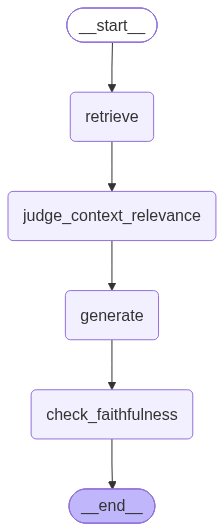

In [9]:
rag_eval_graph

In [ ]:
result = rag_eval_graph.invoke({"query": "What is the time complexity of BST delete?"})

print("Context relevance judgments:", result["relevance_judgments"])
print(f"Context relevance score:      {result['context_relevance_score']:.2f}")
print()
print("Answer:", result["answer"])
print("Claims:", result["claims"])
print("Faithfulness scores:", result["faithfulness_scores"])
print(f"Faithfulness score:           {result['faithfulness_score']:.2f}")

Context relevance judgments: {'c1': 'relevant', 'c2': 'irrelevant', 'c3': 'irrelevant'}
Context relevance score:      0.33

Answer: The time complexity of BST delete is O(h), where h is the height of the tree.
Claims: ['The time complexity of deleting a node from a Binary Search Tree (BST) is O(h).', 'h represents the height of the Binary Search Tree.']
Faithfulness scores: {'The time complexity of deleting a node from a Binary Search Tree (BST) is O(h).': True, 'h represents the height of the Binary Search Tree.': True}
Faithfulness score:           1.00


**Reading the output:** unlike the mock notebook, the exact judgments and claim wording here can vary slightly run-to-run because a real model is making the call (this is itself an interview point — LLM-as-judge is noisier than a deterministic mock, which is why production evals typically run each judge multiple times / use `temperature=0` / track judge-agreement as its own metric).

---
# Part 2b — Full RAG Metric Suite with DeepEval

RAG evaluation splits cleanly along the pipeline's own boundary: **retriever metrics** judge what got fetched, **generator metrics** judge what got produced from it. Part 2 above hand-rolled two of these (context relevance, faithfulness) as bespoke LangGraph nodes. Here we cover the **full table** using [DeepEval](https://github.com/confident-ai/deepeval) — the standard open-source library for exactly this — instead of reimplementing every judge by hand.

| Metric | Stage | Needs ground truth? | Core question |
|---|---|---|---|
| Precision@K | Retriever | Yes (labeled relevant IDs) | How much of what we fetched is noise? |
| Recall@K | Retriever | Yes (labeled relevant IDs) | Did we miss relevant chunks? |
| MRR | Retriever | Yes (labeled relevant IDs) | How early did the first good hit appear? |
| nDCG | Retriever | Yes (graded relevance) | Is the ranking good given graded relevance? |
| **Context Relevance** | Retriever | No (LLM judge) | Is each retrieved chunk on-topic? |
| **Faithfulness / Groundedness** | Generator | No (checks against retrieved context) | Did the model hallucinate beyond the context? |
| **Answer Relevance** | Generator | No (LLM judge vs. query) | Does the answer address the question asked? |
| **Answer Correctness** | Generator | Yes (reference answer) | Is the answer actually right? |
| **Answer Semantic Similarity** | Generator | Yes (reference answer) | How close is the answer to a reference, embedding-wise? |

The first four (Precision@K, Recall@K, MRR, nDCG) are **rank-exact** math over labeled chunk IDs — that's Part 1, and DeepEval doesn't replace it. The **bold** rows below are what we add here: DeepEval ships `ContextualRelevancyMetric` and `FaithfulnessMetric` (professional replacements for the two hand-rolled judges above), plus `AnswerRelevancyMetric`, a `GEval`-based Correctness judge, and — since DeepEval has no dedicated embedding-similarity class — a small manual cosine-similarity helper for Answer Semantic Similarity.

**One test case, six metrics.** DeepEval's unit is an `LLMTestCase` — `input` (the query), `actual_output` (the generated answer), `retrieval_context` (what the retriever fetched), and optionally `expected_output` (a reference answer, needed only by the two metrics that require ground truth). Every metric below runs against the *same* test case built from Part 2's own `result`.

**Note on `async_mode=False`:** every DeepEval metric below is created with `async_mode=False`. DeepEval defaults to `async_mode=True`, dispatching its judge calls through an async OpenAI client — on some environments (seen here on Windows) that path hangs indefinitely per call until DeepEval's own retry timeout fires (`call timed out after ~90s`), even though a plain synchronous OpenAI call from the same environment returns in under 2 seconds. `async_mode=False` forces the synchronous client instead, which is unaffected. If your environment doesn't hit this, the `async_mode` arg is safe to drop.

In [13]:
!pip install deepeval

  Using cached portalocker-4.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached pyfiglet-1.0.4-py3-none-any.whl.metadata (7.4 kB)
  Using cached pytest_asyncio-1.4.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached pytest_repeat-0.9.4-py3-none-any.whl.metadata (4.9 kB)
  Using cached pytest_xdist-3.8.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached backoff-2.2.1-py3-none-any.whl.metadata (14 kB)
  Using cached pydantic_core-2.46.4-cp312-cp312-win_amd64.whl.metadata (6.7 kB)
  Using cached pytest-9.1.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached execnet-2.1.2-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ------------------------------------- -- 1.0/1.1 MB 52.4 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 2.4 MB/s eta 0:00:00
   ----------------------------------

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.3.26 requires langchain<1.0.0,>=0.3.26, but you have langchain 1.3.15 which is incompatible.
langchain-community 0.3.26 requires langchain-core<1.0.0,>=0.3.66, but you have langchain-core 1.5.5 which is incompatible.
spyder 5.5.1 requires ipython!=8.17.1,<9.0.0,>=8.13.0; python_version > "3.8", but you have ipython 9.2.0 which is incompatible.


In [14]:
# pip install deepeval

from deepeval.metrics import (
    AnswerRelevancyMetric,
    ContextualRelevancyMetric,
    FaithfulnessMetric,
    GEval,
)
from deepeval.test_case import LLMTestCase, LLMTestCaseParams

DEEPEVAL_MODEL = MODEL_NAME  # reuse the same "gpt-4o-mini" as judge model DeepEval calls internally

# A hand-written reference answer -- only the two GROUND-TRUTH metrics (Correctness,
# Semantic Similarity) need this; the other three judge the answer on its own terms.
reference_answer = "Deleting a node from a BST takes O(h) time, where h is the height of the tree."

# Build ONE test case from Part 2's own pipeline result -- every metric below scores this same case.
rag_test_case = LLMTestCase(
    input=result["query"] if "query" in result else query,
    actual_output=result["answer"],
    retrieval_context=[c["text"] for c in result["retrieved_chunks"]],
    expected_output=reference_answer,
)

print("Test case built from the live Part 2 run:")
print("  input:            ", rag_test_case.input)
print("  actual_output:    ", rag_test_case.actual_output)
print("  retrieval_context:", rag_test_case.retrieval_context)
print("  expected_output:  ", rag_test_case.expected_output)

c:\Users\Acer\anaconda3\Lib\site-packages\pydantic\_internal\_fields.py:161: UserWarning: Field "model_settings" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  alias, validation_alias, serialization_alias = None, None, None


Test case built from the live Part 2 run:
  input:             What is the time complexity of BST delete?
  actual_output:     The time complexity of BST delete is O(h), where h is the height of the tree.
  retrieval_context: ['BST delete runs in O(h) time where h is tree height.', 'The successor node is the leftmost node of the right subtree.', 'Unrelated: Python lists are dynamic arrays.']
  expected_output:   Deleting a node from a BST takes O(h) time, where h is the height of the tree.


C:\Users\Acer\AppData\Local\Temp\ipykernel_44508\2295726006.py:9: DeprecationWarning: 'LLMTestCaseParams' is deprecated and will be removed in a future release. Use 'SingleTurnParams' instead.
  from deepeval.test_case import LLMTestCase, LLMTestCaseParams


### Retriever metric: Context Relevance

In [ ]:
contextual_relevancy = ContextualRelevancyMetric(
    model=DEEPEVAL_MODEL, threshold=0.5, include_reason=True,
    async_mode=False,  # see note above -- default async path hangs in this environment
)
contextual_relevancy.measure(rag_test_case)

print(f"Context Relevance score: {contextual_relevancy.score:.2f}  (threshold {contextual_relevancy.threshold})")
print("Reason:", contextual_relevancy.reason)

### Generator metrics that need no ground truth: Faithfulness, Answer Relevance

Both judge the answer against things already in the test case (`retrieval_context`, `input`) — no reference answer required, same as the hand-rolled Part 2 judges. `FaithfulnessMetric` is a drop-in professional replacement for `check_faithfulness_node`'s claim-extraction-then-check logic above; `AnswerRelevancyMetric` is new — it checks the answer actually addresses the *question*, independent of whether it's grounded (an answer can be perfectly faithful to context yet still evasive or off-topic).

In [ ]:
faithfulness = FaithfulnessMetric(
    model=DEEPEVAL_MODEL, threshold=0.5, include_reason=True,
    async_mode=False,  # see note above -- default async path hangs in this environment
)
faithfulness.measure(rag_test_case)
print(f"Faithfulness score:     {faithfulness.score:.2f}  (threshold {faithfulness.threshold})")
print("Reason:", faithfulness.reason)
print()

answer_relevancy = AnswerRelevancyMetric(
    model=DEEPEVAL_MODEL, threshold=0.5, include_reason=True,
    async_mode=False,
)
answer_relevancy.measure(rag_test_case)
print(f"Answer Relevance score: {answer_relevancy.score:.2f}  (threshold {answer_relevancy.threshold})")
print("Reason:", answer_relevancy.reason)

### Generator metrics that need ground truth: Answer Correctness, Answer Semantic Similarity

Both compare `actual_output` against `expected_output` (the `reference_answer` defined above) — the two rows in the table marked "Yes" under ground truth.

- **Answer Correctness** has no dedicated DeepEval class (unlike Faithfulness/Relevancy), because "is it factually right" is inherently criteria-specific — so DeepEval's own recommended pattern is `GEval` with a custom rubric. This is a real distinction worth stating out loud: Correctness and Faithfulness sound similar but check different things — an answer can be perfectly grounded in retrieved context yet still wrong if *the retrieved context itself* was outdated or incorrect.
- **Answer Semantic Similarity** isn't a DeepEval metric class at all — it's cheap embedding cosine similarity, no LLM judge call needed. Implemented directly below with `OpenAIEmbeddings`, consistent with the table's note that it's "cheap and fast... but weaker at catching subtle factual errors" (two answers can be semantically close while disagreeing on a key number).

In [ ]:
answer_correctness = GEval(
    name="Answer Correctness",
    criteria="Determine whether the actual output is factually correct relative to the expected output. "
             "Focus on whether the key facts (numbers, complexities, entities) match -- wording may differ.",
    evaluation_params=[LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT, LLMTestCaseParams.EXPECTED_OUTPUT],
    model=DEEPEVAL_MODEL,
    threshold=0.5,
    async_mode=False,  # see note above -- default async path hangs in this environment
)
answer_correctness.measure(rag_test_case)
print(f"Answer Correctness score: {answer_correctness.score:.2f}  (threshold {answer_correctness.threshold})")
print("Reason:", answer_correctness.reason)

In [ ]:
import numpy as np
from langchain_openai import OpenAIEmbeddings

embedder = OpenAIEmbeddings(model="text-embedding-3-small")

def cosine_similarity(a, b):
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

vec_actual, vec_reference = embedder.embed_documents([rag_test_case.actual_output, rag_test_case.expected_output])
semantic_similarity_score = cosine_similarity(vec_actual, vec_reference)

print(f"Answer Semantic Similarity score: {semantic_similarity_score:.3f}  (cosine similarity, no LLM judge)")

In [ ]:
print("=== Full RAG metric suite (one test case) ===")
print(f"{'Metric':<28}{'Stage':<12}{'Ground truth?':<15}Score")
print(f"{'Context Relevance':<28}{'Retriever':<12}{'No':<15}{contextual_relevancy.score:.2f}")
print(f"{'Faithfulness':<28}{'Generator':<12}{'No':<15}{faithfulness.score:.2f}")
print(f"{'Answer Relevance':<28}{'Generator':<12}{'No':<15}{answer_relevancy.score:.2f}")
print(f"{'Answer Correctness':<28}{'Generator':<12}{'Yes':<15}{answer_correctness.score:.2f}")
print(f"{'Answer Semantic Similarity':<28}{'Generator':<12}{'Yes':<15}{semantic_similarity_score:.2f}")

**Reading the table:** notice Context Relevance and Faithfulness here are DeepEval's judgment on the *same* pipeline output that Part 2's hand-rolled nodes already scored — in production you'd pick **one** implementation, not both; they're kept side by side in this notebook purely for comparison. The two ground-truth metrics (Correctness, Semantic Similarity) only exist because we supplied `reference_answer` by hand — in a real eval harness that reference comes from a curated golden dataset, which is also exactly what makes those two metrics expensive to scale (someone has to write and maintain the reference answers) versus the reference-free metrics above them, which run against *any* query with no labeling effort.

<a id="part-7"></a>
# Part 7 — Agent Trajectory Evaluation (Real OpenAI Tool-Calling Agent)

_Source: `04_Agent_RAG_Eval/rag_agent_eval_langgraph_openai.ipynb`, cells 29-37 (unmodified). Live-LLM counterpart to Part 5's simple agent graph: real tools (`search_docs`, `calculator`, `send_email`) bound to a real LLM via LangGraph, closing with the notebook's own summary table._

---
# Part 3 — Agent Eval Pipeline as a LangGraph Graph (real OpenAI tool-calling agent)

**Interview questions covered:**
- *How would you evaluate whether the agent selected the right tool?*
- *How would you measure task completion?*
- *What happens when the agent takes the wrong action?*
- *How would you evaluate multi-step tasks?*
- *How would you detect unnecessary tool calls?*

This time the planner is a real `ChatOpenAI` model with tools bound via `bind_tools` — the model itself decides which tool to call, with what arguments, and when it's done. The graph loops `agent -> tools -> agent -> ...` until the model responds without requesting a tool call, then hands the resulting trace to a separate `evaluate` node that scores it against a gold trajectory (mirrors real practice: the agent never grades itself).

In [11]:
# ---- Real tools the agent can call ----

@tool
def search_docs(topic: str) -> str:
    """Search internal docs for information about a topic."""
    return f"docs about {topic}: BST delete runs in O(h) time where h is tree height."


@tool
def calculator(expr: str) -> str:
    """Evaluate a simple arithmetic expression, e.g. '2**10'."""
    allowed = set("0123456789+-*/(). ")
    if not set(expr) <= allowed:
        return "error: expression contains disallowed characters"
    return str(eval(expr, {"__builtins__": {}}, {}))


@tool
def send_email(to: str, body: str) -> str:
    """Send an email to a recipient."""
    return f"email sent to {to}"


TOOLS = [search_docs, calculator, send_email]
TOOLS_BY_NAME = {t.name: t for t in TOOLS}
agent_llm = llm.bind_tools(TOOLS)

print("Tools registered:", list(TOOLS_BY_NAME.keys()))

Tools registered: ['search_docs', 'calculator', 'send_email']


In [12]:
class AgentEvalState(TypedDict):
    query: str
    gold_tool_sequence: List[str]     # ground truth trajectory, defined by the eval harness
    messages: List                    # the real conversation, incl. tool calls/results
    trace: List[Dict]                 # [{"tool", "args", "result", "used"}]
    final_answer: Optional[str]
    task_success: Optional[bool]
    tool_selection_correct: List[bool]
    unnecessary_calls: List[str]

In [13]:
MAX_STEPS = 6  # safety cap so a misbehaving agent can't loop forever


def agent_node(state: AgentEvalState) -> AgentEvalState:
    if not state["messages"]:
        state["messages"] = [
            SystemMessage("You are a helpful assistant. Use tools when needed to answer the "
                          "user's request, then give a final natural-language answer. Do not "
                          "call the same tool with the same arguments twice."),
            HumanMessage(state["query"]),
        ]

    response: AIMessage = agent_llm.invoke(state["messages"])
    state["messages"] = state["messages"] + [response]

    if not response.tool_calls:
        state["final_answer"] = response.content

    return state


def tools_node(state: AgentEvalState) -> AgentEvalState:
    last_message: AIMessage = state["messages"][-1]
    tool_messages = []

    for call in last_message.tool_calls:
        tool_name, args = call["name"], call["args"]

        # A call is "unnecessary" if the exact same (tool, args) already ran --
        # the result would be identical, so it added no new information.
        is_duplicate = any(t["tool"] == tool_name and t["args"] == args for t in state["trace"])

        result = TOOLS_BY_NAME[tool_name].invoke(args)
        state["trace"].append({
            "tool": tool_name, "args": args, "result": result, "used": not is_duplicate,
        })
        tool_messages.append(ToolMessage(content=str(result), tool_call_id=call["id"]))

    state["messages"] = state["messages"] + tool_messages
    return state


def should_continue(state: AgentEvalState) -> str:
    if state.get("final_answer") is not None:
        return "evaluate"
    if len(state["trace"]) >= MAX_STEPS:
        state["final_answer"] = "Task stopped: exceeded max tool-call budget."
        return "evaluate"
    return "tools"


def evaluate_node(state: AgentEvalState) -> AgentEvalState:
    actual_tools = [t["tool"] for t in state["trace"]]
    gold_tools = state["gold_tool_sequence"]

    # Step-wise trajectory match against the gold sequence -- this is how you
    # evaluate MULTI-STEP tasks: score each step, not just the final answer.
    correctness = [
        (actual_tools[i] if i < len(actual_tools) else None) == gold_tools[i]
        for i in range(len(gold_tools))
    ]
    state["tool_selection_correct"] = correctness

    # Flags raised during the trace itself -- redundant calls with no new info.
    state["unnecessary_calls"] = [t["tool"] for t in state["trace"] if not t["used"]]

    # Task completion = reached a final answer AND every gold step was matched.
    state["task_success"] = (
        state["final_answer"] is not None and sum(correctness) == len(gold_tools)
    )
    return state


print("Nodes defined (agent_node calls the real OpenAI model)")

Nodes defined (agent_node calls the real OpenAI model)


In [14]:
builder = StateGraph(AgentEvalState)
builder.add_node("agent", agent_node)
builder.add_node("tools", tools_node)
builder.add_node("evaluate", evaluate_node)

builder.set_entry_point("agent")
builder.add_conditional_edges("agent", should_continue, {"tools": "tools", "evaluate": "evaluate"})
builder.add_edge("tools", "agent")
builder.add_edge("evaluate", END)

agent_eval_graph = builder.compile()
print("Graph compiled: agent <-> tools (loops), agent -> evaluate -> END")

Graph compiled: agent <-> tools (loops), agent -> evaluate -> END


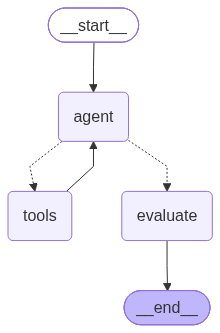

In [15]:
agent_eval_graph

In [16]:
initial_state: AgentEvalState = {
    "query": "Look up BST delete complexity and compute 2^10",
    "gold_tool_sequence": ["search_docs", "calculator"],   # the IDEAL 2-step trajectory
    "messages": [],
    "trace": [],
    "final_answer": None,
    "task_success": None,
    "tool_selection_correct": [],
    "unnecessary_calls": [],
}

result = agent_eval_graph.invoke(initial_state)

print("=== Trace ===")
for i, step in enumerate(result["trace"]):
    print(f"  Step {i}: {step['tool']}({step['args']}) -> {step['result']!r}  | used={step['used']}")

print()
print("=== Eval ===")
print("Tool selection correctness vs gold:", result["tool_selection_correct"])
print("Unnecessary calls detected:        ", result["unnecessary_calls"])
print("Task success:                      ", result["task_success"])
print("Final answer:                      ", result["final_answer"])

=== Trace ===
  Step 0: search_docs({'topic': 'BST delete complexity'}) -> 'docs about BST delete complexity: BST delete runs in O(h) time where h is tree height.'  | used=True
  Step 1: calculator({'expr': '2**10'}) -> '1024'  | used=True

=== Eval ===
Tool selection correctness vs gold: [True, True]
Unnecessary calls detected:         []
Task success:                       True
Final answer:                       The complexity of deleting a node in a Binary Search Tree (BST) is \( O(h) \), where \( h \) is the height of the tree. 

Additionally, \( 2^{10} \) equals 1024.


**Reading the output:** unlike the mock notebook (which hard-coded a redundant call to *force* the demo), a real, reasonably capable model will usually pick the correct minimal trajectory (`search_docs` then `calculator`) and avoid duplicate calls on its own. That itself is a finding worth stating in an interview: mocked agent demos need synthetic failures injected, but a real deployed agent needs a harness like this `evaluate` node running continuously in production to catch the cases where the model *doesn't* behave well — e.g. try changing the query to something ambiguous, or add a fourth tool the model might reach for unnecessarily, and re-run this cell to see the eval flag it.

---
## Summary — mapping back to the interview answers

| Question | Where in this notebook |
|---|---|
| How would you evaluate retrieval quality? | Part 1 — full metric suite run against a labeled query |
| Precision@K / Recall@K | Part 1 — `precision_at_k`, `recall_at_k` |
| When MRR vs nDCG? | Part 1 — `mrr` (single best answer) vs `ndcg_at_k` (graded, multiple relevant) |
| Context relevance | Part 2 — `judge_context_relevance_node`, real `ChatOpenAI` judge, scored *before* generation; Part 2b — `ContextualRelevancyMetric` (DeepEval) |
| Groundedness / faithfulness | Part 2 — `check_faithfulness_node`, real `ChatOpenAI` claim-by-claim check *after* generation; Part 2b — `FaithfulnessMetric` (DeepEval) |
| Answer relevance | Part 2b — `AnswerRelevancyMetric`: does the answer address the question, independent of groundedness? |
| Answer correctness | Part 2b — `GEval` custom rubric vs. a reference answer; distinct from faithfulness (grounded ≠ right if the context itself was wrong) |
| Answer semantic similarity | Part 2b — manual cosine similarity over `OpenAIEmbeddings`; cheap/fast but weaker at catching subtle factual errors |
| Right tool selected? | Part 3 — `tool_selection_correct`, step-wise match vs gold trajectory, produced by a real tool-calling agent |
| Task completion | Part 3 — `task_success`, requires final answer AND full trajectory match |
| Wrong action taken | Part 3 — the `evaluate` node catches it post-hoc; a production system would also guard pre-call (e.g. dedupe check before invoking) |
| Multi-step evaluation | Part 3 — step-wise trajectory scoring over a real `agent <-> tools` loop, not just final-answer scoring |
| Unnecessary tool calls | Part 3 — `unnecessary_calls`, duplicate `(tool, args)` detection against the live trace |